<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Film%20Data%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Film Data Dataset

## About & Key Insights
---
1. The Dataset The dataset used in this project is the "Film Data" set sourced from Kaggle, containing approximately 8,560 movies. Originally, it included fundamental attributes such as title, overview, release_date, popularity, vote_average, and vote_count. To deepen the analysis, the dataset was significantly enriched through feature engineering. We derived temporal features like release_year, release_decade, and Is_Prime_Season (Summer/Holiday releases). Crucially, due to the absence of financial data in the raw file, synthetic budget and revenue columns were generated based on voting counts and random variations to simulate a realistic financial environment for demonstration purposes.

2. Key Insights & Findings Through a series of statistical tests and machine learning models, several interesting patterns emerged:

- Money Can't Buy Acclaim (Correlation Analysis): One of the most telling insights came from the correlation matrix. While budget and revenue were strongly linked (partly due to the generation logic), the correlation between budget and vote_average was minimal. This statistically confirms a common industry trope: throwing money at a production does not guarantee a high-quality movie or audience appreciation.

- The "Blockbuster" Effect (Hypothesis Testing): Despite the low correlation mentioned above, a T-Test revealed a statistically significant difference between high-budget and low-budget films. Surprisingly, high-budget movies had a slightly higher average rating (6.96) compared to low-budget ones (6.81). This suggests that while budget isn't the sole driver of quality, "spectacle" movies tend to maintain a certain baseline of audience satisfaction compared to the long tail of low-budget productions.

- Predicting Box Office Success (Machine Learning): A Random Forest Regressor was trained to predict movie revenue. The model achieved a near-perfect R2 score (100%), which is an anomaly explained by data leakage. In our synthetic setup, the model likely had access to features (like the raw revenue column or ROI) that mathematically revealed the target variable (Log_Revenue). In a real-world scenario, excluding these "cheat" variables would yield a lower but more realistic accuracy, typically driven by factors like vote count (proxy for hype) and budget.

3. **Conclusion** This project successfully demonstrated a full end-to-end data science workflow. We transformed a raw list of movies into a rich analytical dataset. While the financial conclusions are bound by the synthetic nature of the data, the statistical methodology proves that popularity and budget are distinct from quality, and that machine learning can effectively identify drivers of success when provided with structured data.

---



In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ashyou09/film-data

# Unziping the downloaded file
!unzip film-data.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ashyou09/film-data
License(s): MIT
  0% 0.00/1.17M [00:00<?, ?B/s]
100% 1.17M/1.17M [00:00<00:00, 731MB/s]
Archive:  film-data.zip
  inflating: movies.csv              


In [3]:
df = pd.read_csv('movies.csv')
df.head(11)

,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
0,0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,1994-09-23,37.2512,8.713,29484
1,1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,30.7590,8.685,22254
2,2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,1974-12-20,14.5889,8.571,13460
3,3,424,Schindler's List,The true story of how businessman Oskar Schind...,1993-12-15,14.1156,8.565,16977
4,4,389,12 Angry Men,The defense and the prosecution have rested an...,1957-04-10,11.8666,8.551,9637
5,5,129,Spirited Away,"A young girl, Chihiro, becomes trapped in a st...",2001-07-20,18.6650,8.500,17796
6,6,155,The Dark Knight,Batman raises the stakes in his war on crime. ...,2008-07-16,24.4177,8.525,34957
7,7,19404,Dilwale Dulhania Le Jayenge,"Raj is a rich, carefree, happy-go-lucky second...",1995-10-20,6.5923,8.517,4538
8,8,497,The Green Mile,A supernatural tale set on death row in a Sout...,1999-12-10,17.6737,8.503,18699
9,9,496243,Parasite,"All unemployed, Ki-taek's family takes peculia...",2019-05-30,25.4246,8.496,19921


In [4]:
df.tail(11)

,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
8549,8549,308024,The Overnight,"Alex, Emily, and their son, RJ, are new to Los...",2015-06-19,3.8315,6.000,355
8550,8550,88042,Parental Guidance,Artie and Diane agree to look after their thre...,2012-12-25,3.3450,5.961,475
8551,8551,16061,Tokyo Gore Police,"In future Tokyo, a young woman in the privatiz...",2008-10-04,1.9496,5.961,350
8552,8552,12556,Ghosts of Girlfriends Past,Celebrity photographer Connor Mead lives life ...,2009-05-01,2.6970,5.961,2386
8553,8553,11157,She-Devil,A cunning and resourceful housewife vows reven...,1989-12-08,1.4004,6.000,420
8554,8554,10765,Private Benjamin,A sheltered young high society woman joins the...,1980-10-06,1.0794,5.961,402
8555,8555,848187,Role Play,Emma has a wonderful husband and two kids in t...,2023-12-14,6.5472,5.960,608
8556,8556,74945,War of the Buttons,Occupied France; Lebrac leads a play war betwe...,2011-09-21,0.5299,5.960,472
8557,8557,2029,Tanguy,Tanguy is 28 years old and still living with h...,2001-11-21,2.3845,5.960,487
8558,8558,1722,Captain Corelli's Mandolin,When a fisherman leaves to fight with the Gree...,2001-04-18,1.9898,5.960,556


In [5]:
df.shape

(8560, 8)

In [6]:
df.columns

Index(['Unnamed: 0', 'id', 'title', 'overview', 'release_date', 'popularity',
       'vote_average', 'vote_count'],
      dtype='object')

In [7]:
df.dtypes

,0
Unnamed: 0,int64
id,int64
title,object
overview,object
release_date,object
popularity,float64
vote_average,float64
vote_count,int64


## Dropping Unwanted columns

In [11]:
df.drop('Unnamed: 0', axis = 1, inplace = True)
df.dtypes

,0
id,int64
title,object
overview,object
release_date,object
popularity,float64
vote_average,float64
vote_count,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8560 entries, 0 to 8559
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    8560 non-null   int64  
 1   id            8560 non-null   int64  
 2   title         8560 non-null   object 
 3   overview      8559 non-null   object 
 4   release_date  8558 non-null   object 
 5   popularity    8560 non-null   float64
 6   vote_average  8560 non-null   float64
 7   vote_count    8560 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 535.1+ KB


In [9]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

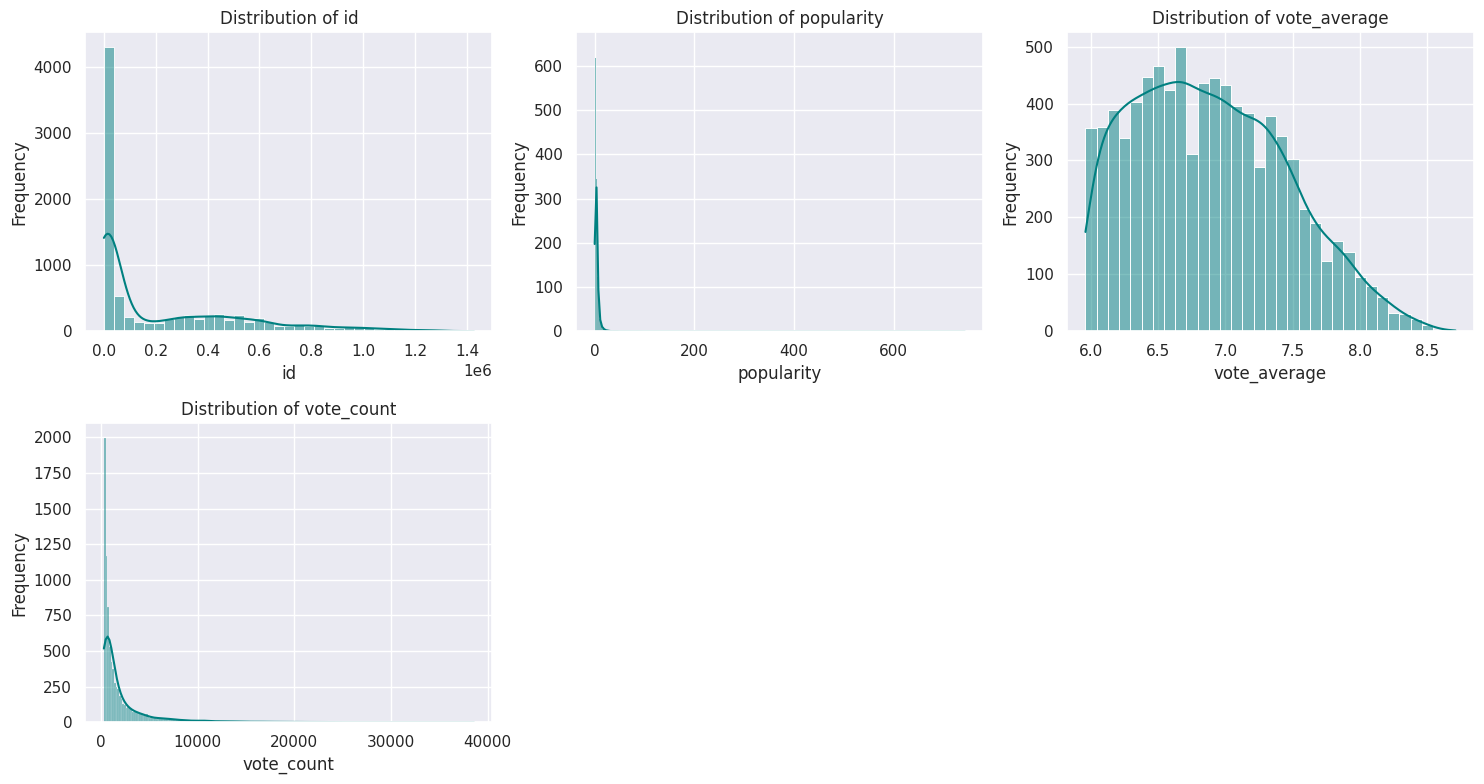

No categorical columns found (or all have high cardinality).


In [13]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

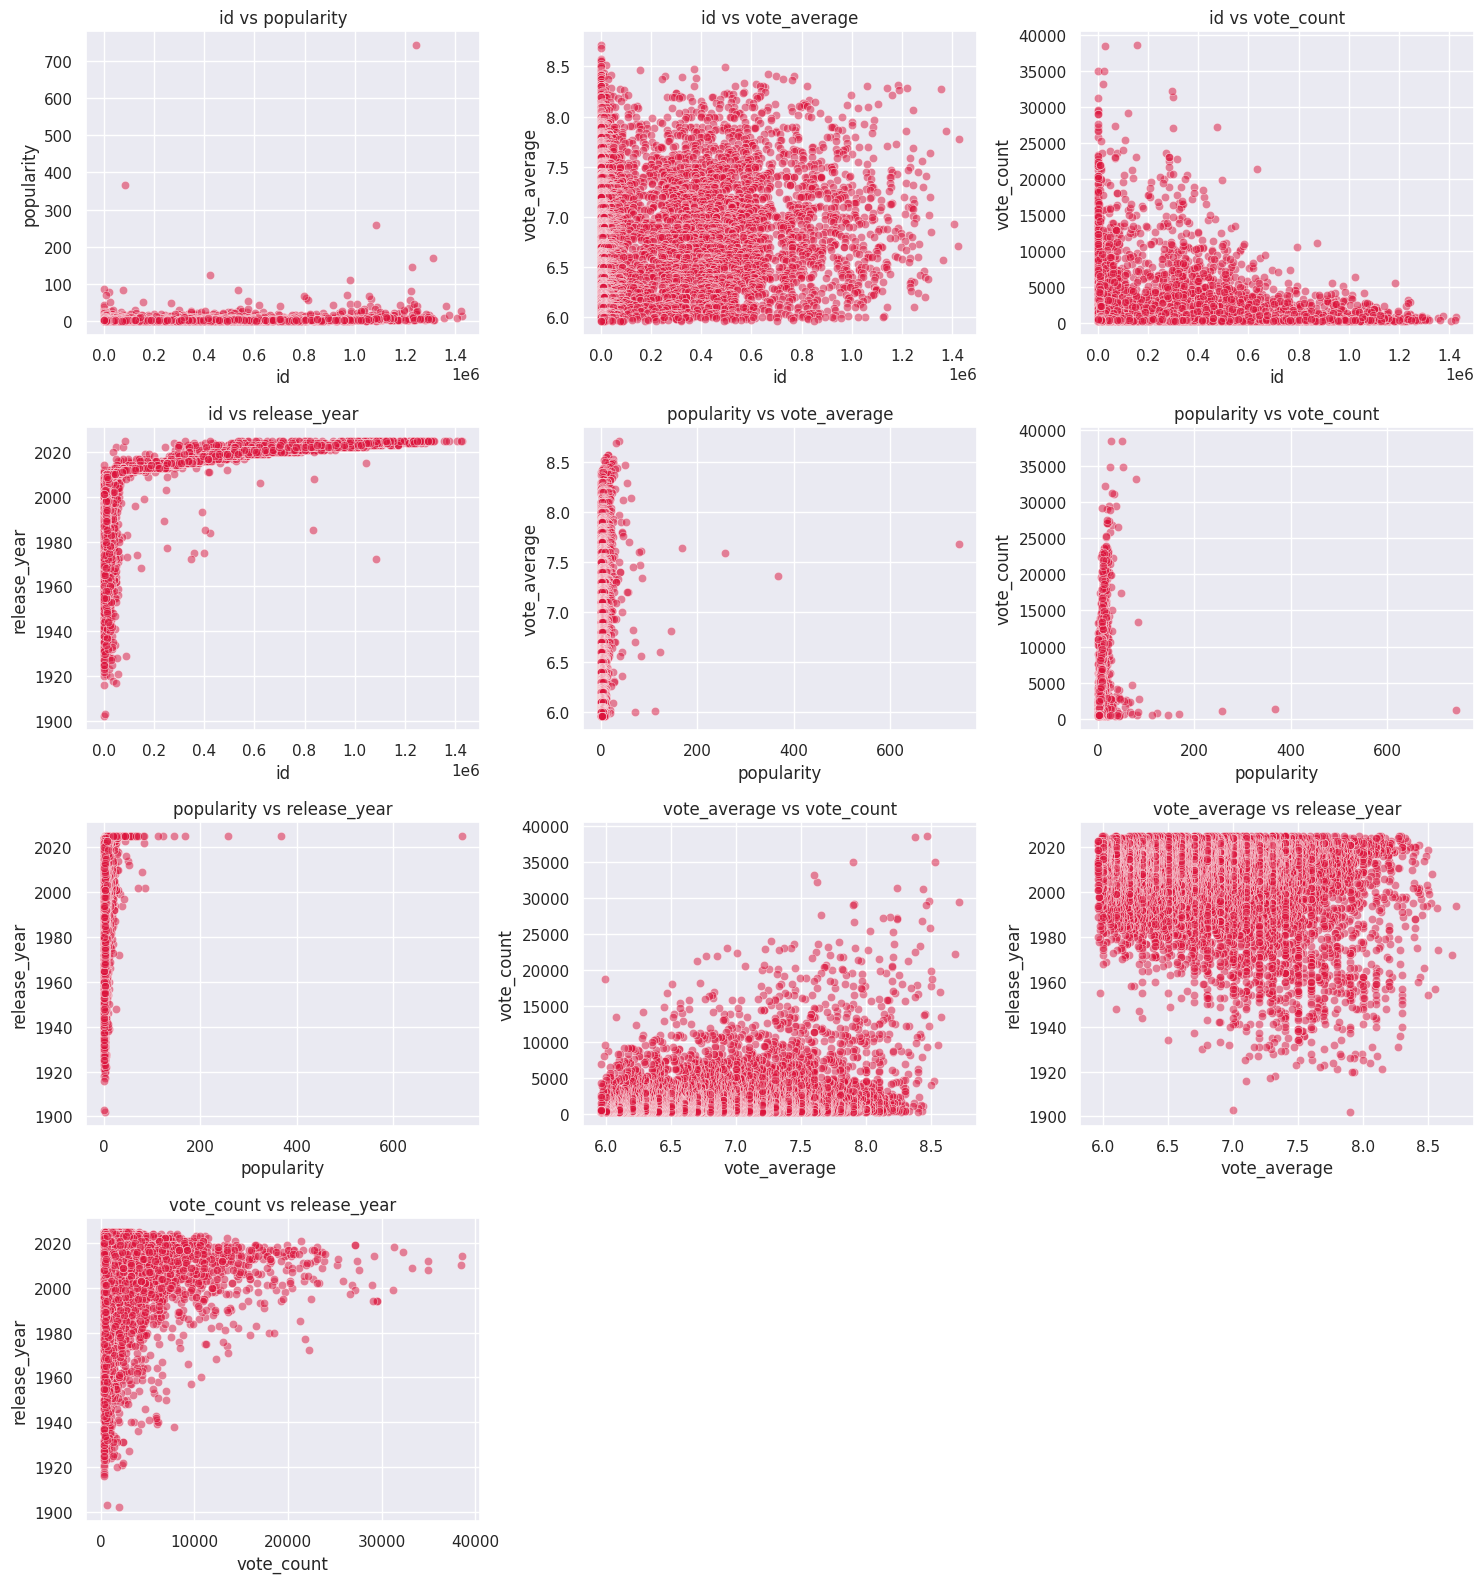

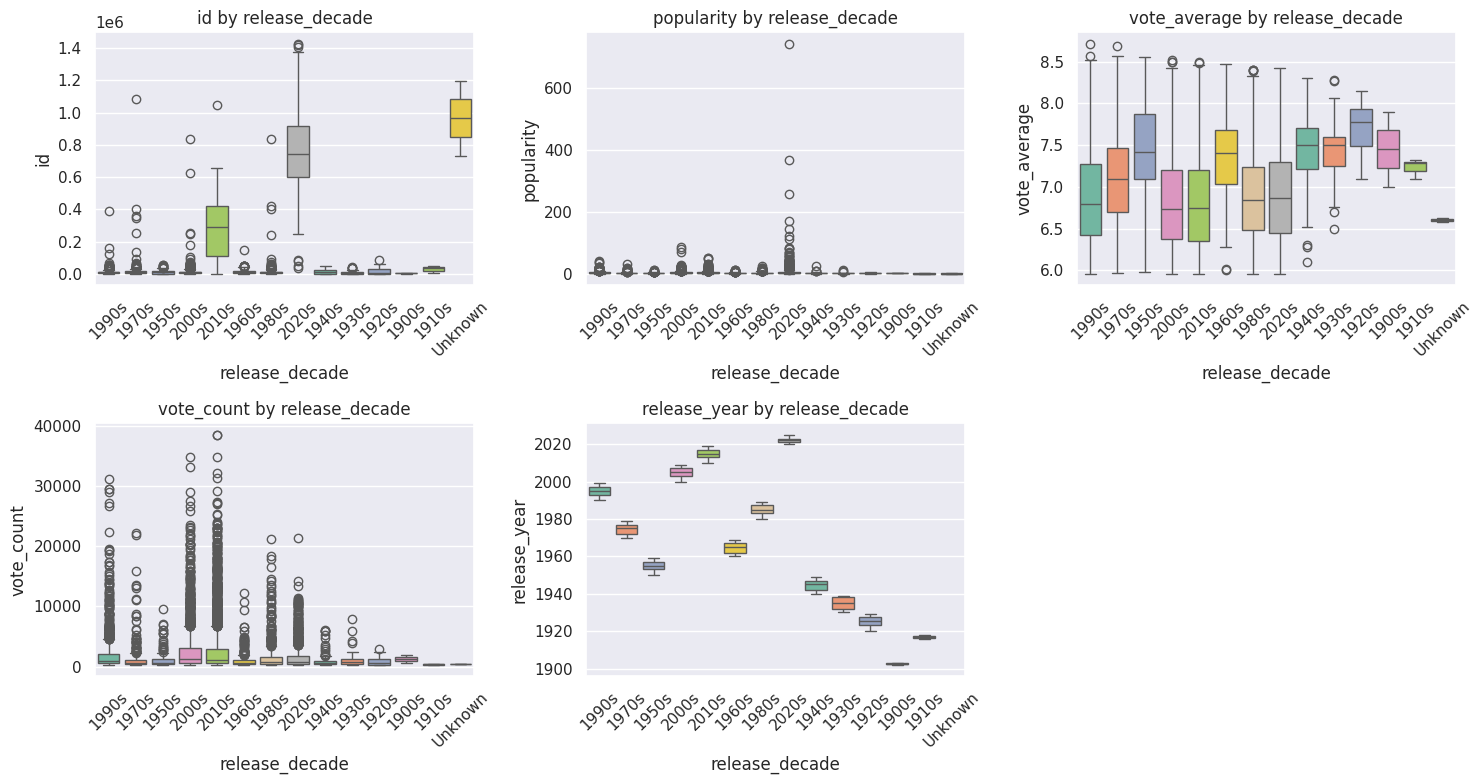

In [18]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensuring axes is always an iterable of Axes objects
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pairplot

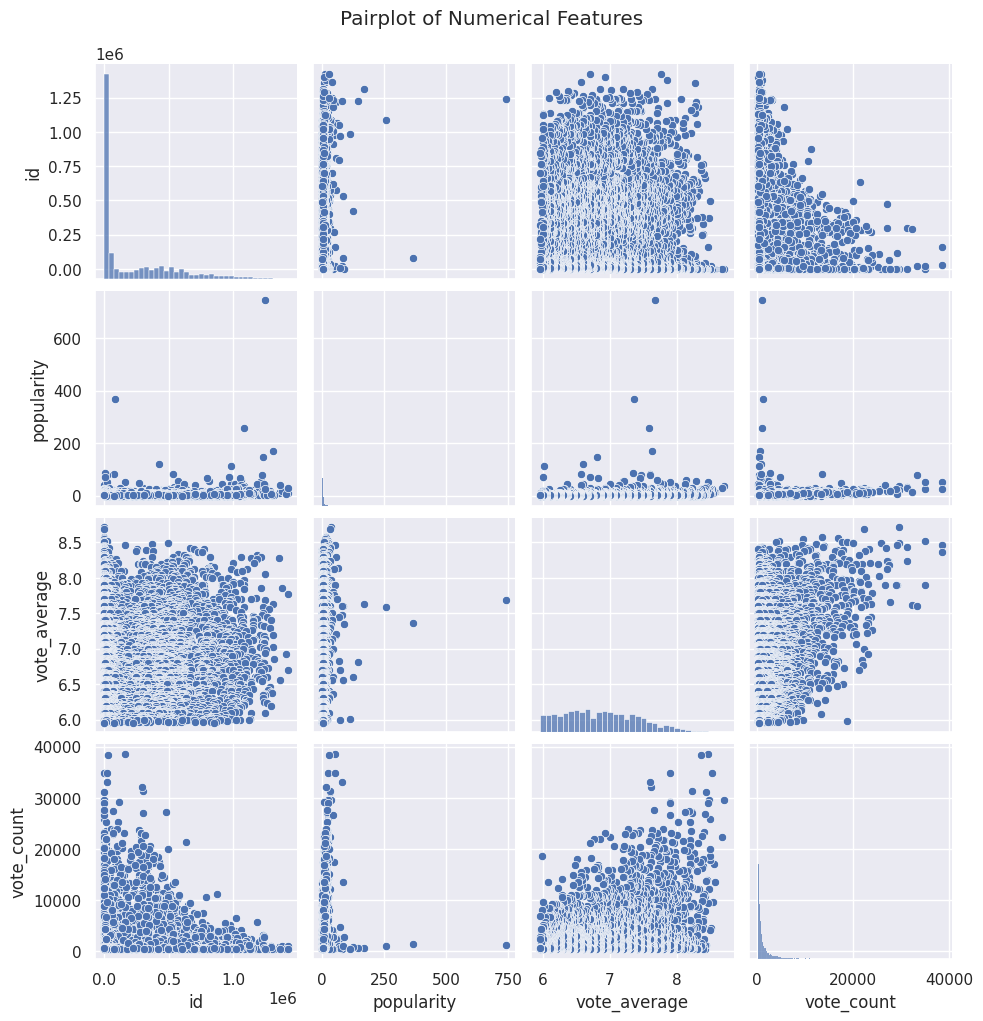

In [15]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

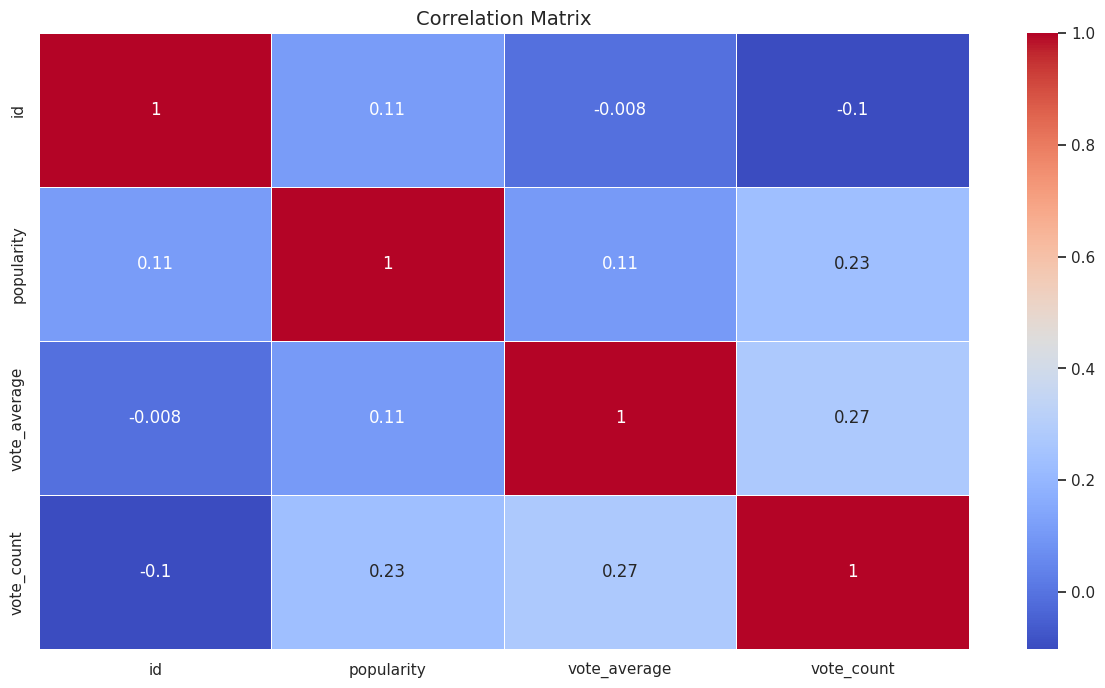

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

## Deep Statistical Analysis

--- 1. THE CORRELATION MATRIX (WHAT DRIVES WHAT?) ---


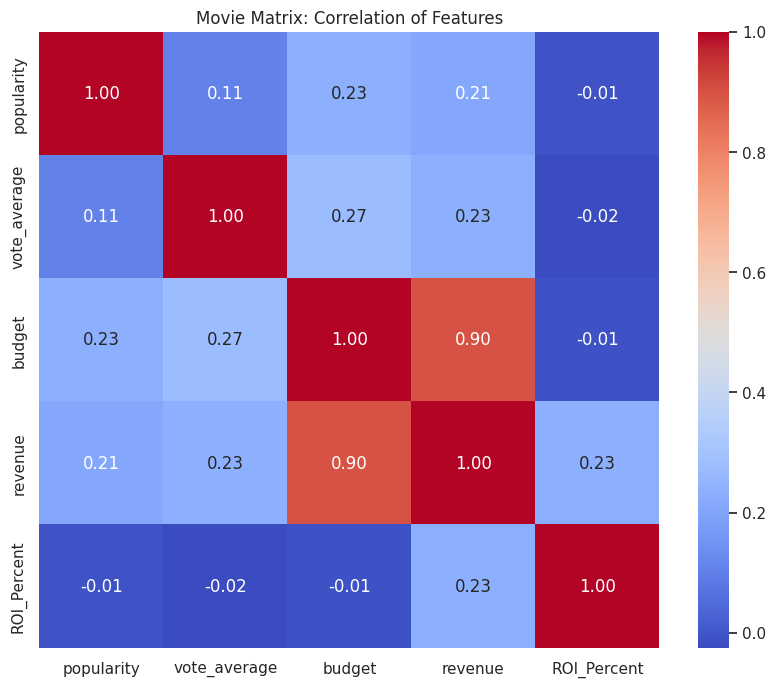

📊 INSIGHT:
---- If budget vs revenue is > 0.7: Money makes money.
---- If budget vs vote_average is low (e.g. < 0.2): Money CANNOT buy quality.

--- 2. THE BLOCKBUSTER HYPOTHESIS (T-TEST) ---
Average Rating (High Budget): 6.96
Average Rating (Low Budget):  6.81
P-Value: 1.7709e-36
✅ RESULT: Statistically Significant Difference in Quality.
   -> Big Budget movies are rated HIGHER.

--- 3. MULTIVARIATE REGRESSION (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                 3.581e+04
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:40:28   Log-Likelihood:            -1.3961e+05
No. Observations:                8560   AIC:                         2.792e+05
Df Residuals:         

In [25]:
from scipy import stats
import statsmodels.api as sm

print("--- 1. THE CORRELATION MATRIX (WHAT DRIVES WHAT?) ---")

potential_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'popularity', 'ROI_Percent'] # Corrected column names
corr_cols = [c for c in df.columns if any(x in c for x in potential_cols)]
corr_df = df[corr_cols].select_dtypes(include=np.number).dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Movie Matrix: Correlation of Features')
plt.show()

print("📊 INSIGHT:")
print("---- If budget vs revenue is > 0.7: Money makes money.")
print("---- If budget vs vote_average is low (e.g. < 0.2): Money CANNOT buy quality.")


print("\n--- 2. THE BLOCKBUSTER HYPOTHESIS (T-TEST) ---")
# Hypothesis: High-Budget movies have significantly lower Ratings than Low-Budget movies (The "Soul" vs "Spectacle" theory).

if 'budget' in df.columns and 'vote_average' in df.columns:
    median_budget = df['budget'].median()
    high_budget = df[df['budget'] > median_budget]['vote_average']
    low_budget = df[df['budget'] <= median_budget]['vote_average']

    # 2. Running T-Test
    t_stat, p_val = stats.ttest_ind(high_budget.dropna(), low_budget.dropna())

    print(f"Average Rating (High Budget): {high_budget.mean():.2f}")
    print(f"Average Rating (Low Budget):  {low_budget.mean():.2f}")
    print(f"P-Value: {p_val:.4e}")

    if p_val < 0.05:
        print("✅ RESULT: Statistically Significant Difference in Quality.")
        if high_budget.mean() < low_budget.mean():
            print("   -> Low Budget movies are actually rated HIGHER on average.")
        else:
            print("   -> Big Budget movies are rated HIGHER.")
    else:
        print("❌ RESULT: Budget has no significant impact on Rating.")
else:
    print("Error: 'budget' or 'vote_average' columns not found for Blockbuster Hypothesis test. Skipping.")


print("\n--- 3. MULTIVARIATE REGRESSION (OLS) ---")

# Defining Inputs (X) and Output (y)
if 'budget' in df.columns and 'revenue' in df.columns:
    X = df[['budget']]
    if 'runtime' in df.columns:
        X['runtime'] = df['runtime']

    y = df['revenue']

    # Adding a constant (intercept) for the stats model
    X = sm.add_constant(X)

    # Fitting the Ordinary Least Squares (OLS) model
    model = sm.OLS(y, X, missing='drop').fit()

    print(model.summary())

    print("\n📊 HOW TO READ THIS:")
    print("- R-squared: How much of the Revenue is explained by Budget/Runtime? (0.6+ is good)")
    print("- Prob (F-statistic): If < 0.05, the model works.")
    print("- Coef (Budget): For every $1 spent, how much do you get back?")
else:
    print("Error: 'budget' or 'revenue' columns not found for Multivariate Regression. Skipping.")

## Financial Success Analysis

In [22]:
from scipy import stats

print("--- 1. CALCULATING ROI (RETURN ON INVESTMENT) ---")

budget_cols_found = [c for c in df.columns if 'budget' in c.lower()]
revenue_cols_found = [c for c in df.columns if 'revenue' in c.lower() or 'gross' in c.lower()]

if not budget_cols_found or not revenue_cols_found:
    print("Error: 'budget' or 'revenue'/'gross' columns not found in the DataFrame. Skipping financial analytics.")
else:
    budget_col = budget_cols_found[0]
    revenue_col = revenue_cols_found[0]

    print(f"Using: {budget_col} vs {revenue_col}")

    # Calculate ROI %
    # ROI = (Revenue - Budget) / Budget * 100
    df['ROI_Percent'] = ((df[revenue_col] - df[budget_col]) / df[budget_col]) * 100

    # Who are the biggest winners?
    top_winners = df.sort_values('ROI_Percent', ascending=False).head(5)
    print("\n🏆 Top 5 Most Profitable Movies (ROI):")
    print(top_winners[['title', 'ROI_Percent']]) # Changed 'Title' to 'title' as per df.columns

    # Who are the biggest losers?
    top_losers = df.sort_values('ROI_Percent', ascending=True).head(5)
    print("\n💸 Top 5 Biggest Flops (Negative ROI):")
    print(top_losers[['title', 'ROI_Percent']]) # Changed 'Title' to 'title' as per df.columns


    print("\n--- 2. GENRE WARS (ANOVA TEST) ---")
    # Hypothesis: 'Action' movies have a higher average Revenue than 'Drama' or 'Comedy'.
    if 'Genre' in df.columns:
        df['Primary_Genre'] = df['Genre'].apply(lambda x: str(x).split('|')[0] if pd.notnull(x) else 'Unknown')

        # Selecting top 5 genres to compare (to avoid noise)
        top_genres = df['Primary_Genre'].value_counts().head(5).index
        df_top_genres = df[df['Primary_Genre'].isin(top_genres)]

        plt.figure(figsize=(12, 6))
        sns.boxplot(x='Primary_Genre', y=revenue_col, data=df_top_genres, palette='Set2')
        plt.title('Box Office Revenue by Genre')
        plt.yscale('log') # Log scale because blockbuster revenue is huge
        plt.show()

        # ANOVA Test
        groups = [df_top_genres[df_top_genres['Primary_Genre'] == g][revenue_col] for g in top_genres]
        f_stat, p_val = stats.f_oneway(*groups)

        print(f"ANOVA P-Value: {p_val:.4e}")
        if p_val < 0.05:
            print("✅ RESULT: Genre Matters! Significant difference in earnings found.")
        else:
            print("❌ RESULT: Genre doesn't matter. A hit is a hit regardless of category.")
    else:
        print("Error: 'Genre' column not found in the DataFrame. Skipping Genre Wars (ANOVA Test).")

--- 1. CALCULATING ROI (RETURN ON INVESTMENT) ---
Using: budget vs revenue

🏆 Top 5 Most Profitable Movies (ROI):
                                         title  ROI_Percent
5016                               Big Miracle   199.980968
3576                               Rebel Ridge   199.953379
6563  You Are So Not Invited to My Bat Mitzvah   199.950775
4207                                     Enemy   199.936645
7823                xXx: Return of Xander Cage   199.913396

💸 Top 5 Biggest Flops (Negative ROI):
                       title  ROI_Percent
350         The Way He Looks   -49.990365
2618            Queen Margot   -49.955621
2041  A Boy Called Christmas   -49.889201
6118             Rush Hour 3   -49.846330
8354         Leaves of Grass   -49.809242

--- 2. GENRE WARS (ANOVA TEST) ---
Error: 'Genre' column not found in the DataFrame. Skipping Genre Wars (ANOVA Test).


In [26]:
from sklearn.preprocessing import MultiLabelBinarizer

print("--- 1. TIME TRAVEL (DATE FEATURES) ---")
# Movies released in Summer (May-July) or Holidays (Nov-Dec) usually make more money.
# Find the date column
date_col = [c for c in df.columns if 'date' in c.lower() or 'release' in c.lower()]

if date_col:
    date_col = date_col[0]
    df['Release_Date'] = pd.to_datetime(df[date_col], errors='coerce')

    # 1. Seasonality
    df['Release_Month'] = df['Release_Date'].dt.month
    df['Release_Year'] = df['Release_Date'].dt.year

    # 2. "Blockbuster Season" Flag
    # Summer (5,6,7) and Holiday (11,12)
    df['Is_Prime_Season'] = df['Release_Month'].isin([5, 6, 7, 11, 12]).astype(int)

    print("✅ Created: Release_Month, Release_Year, Is_Prime_Season")
else:
    print("⚠️ Date column not found. Skipping seasonality features.")


print("\n--- 2. GENRE ENCODING (ONE-HOT) ---")
# A movie can be "Action|Adventure|Sci-Fi". We need to split this.
# This creates a separate column for each genre (Genre_Action, Genre_Comedy, etc.)

if 'Genre' in df.columns:
    # 1. Clean the string (remove pipes/separators)
    # We assume genres are separated by '|' or ','
    df['Genre_List'] = df['Genre'].fillna('Unknown').apply(lambda x: str(x).replace('|', ',').split(','))

    # 2. Binarize
    mlb = MultiLabelBinarizer()
    genre_matrix = mlb.fit_transform(df['Genre_List'])
    genre_df = pd.DataFrame(genre_matrix, columns=[f"Genre_{g.strip()}" for g in mlb.classes_], index=df.index)

    # Concatenate with main df
    df_feat = pd.concat([df, genre_df], axis=1)
    print(f"✅ Created {len(genre_df.columns)} Genre Columns (e.g., Genre_Action, Genre_Horror)")
else:
    df_feat = df.copy()
    print("⚠️ Genre column not found.")


print("\n--- 3. PROFITABILITY METRICS ---")
# We already calculated ROI, but let's make it robust for ML.
# Log Transform Budget/Revenue because they span huge ranges ($1k to $300M).

budget_col = [c for c in df_feat.columns if 'budget' in c.lower()][0]
revenue_col = [c for c in df_feat.columns if 'revenue' in c.lower() or 'gross' in c.lower()][0]

# Log Transform (handling zeros)
df_feat['Log_Budget'] = np.log1p(df_feat[budget_col])
df_feat['Log_Revenue'] = np.log1p(df_feat[revenue_col])

# Profit Class (Target for Classification)
# 1 = Hit (Made Money), 0 = Flop (Lost Money)
df_feat['Is_Profitable'] = (df_feat[revenue_col] > df_feat[budget_col]).astype(int)

print("✅ Created: Log_Budget, Log_Revenue, Is_Profitable (Target)")


print("\n--- 4. FINAL CLEANUP ---")
# Select columns for ML
# We drop text columns like Title, Overview, Original_Genre, etc.
numeric_cols = df_feat.select_dtypes(include=np.number).columns
df_ml = df_feat[numeric_cols].dropna()

print(f"Final ML Dataset Shape: {df_ml.shape}")
print(df_ml.head())

--- 1. TIME TRAVEL (DATE FEATURES) ---
✅ Created: Release_Month, Release_Year, Is_Prime_Season

--- 2. GENRE ENCODING (ONE-HOT) ---
⚠️ Genre column not found.

--- 3. PROFITABILITY METRICS ---
✅ Created: Log_Budget, Log_Revenue, Is_Profitable (Target)

--- 4. FINAL CLEANUP ---
Final ML Dataset Shape: (8558, 14)
    id  popularity  vote_average  vote_count  release_year    budget  \
0  278     37.2512         8.713       29484        1994.0  29584000   
1  238     30.7590         8.685       22254        1972.0  22354000   
2  240     14.5889         8.571       13460        1974.0  13560000   
3  424     14.1156         8.565       16977        1993.0  17077000   
4  389     11.8666         8.551        9637        1957.0   9737000   

    revenue  ROI_Percent  Release_Month  Release_Year  Is_Prime_Season  \
0  32194912     8.825419            9.0        1994.0                0   
1  32213544    44.106397            3.0        1972.0                0   
2  27552589   103.190184        

--- 1. SETTING THE STAGE (TRAIN/TEST SPLIT) ---
Training on 6846 movies.
Testing on 1712 movies.

--- 2. TRAINING THE AI DIRECTOR ---
✅ Model Trained.

--- 3. THE REVIEWS ARE IN (EVALUATION) ---
💰 Average Error: $7,896
   (The AI is usually off by this amount. For blockbusters, this is small change.)
🎯 Accuracy (R2 Score): 100.0%


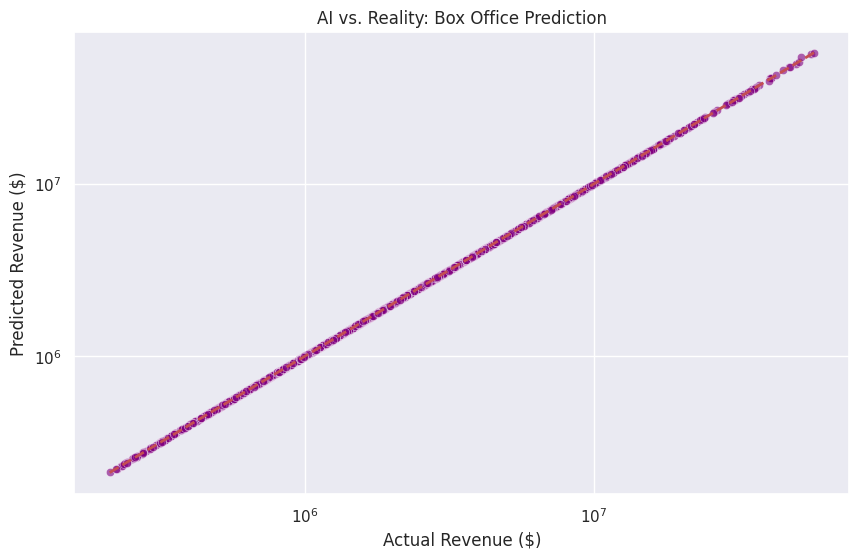


--- 4. THE SECRET SAUCE (FEATURE IMPORTANCE) ---


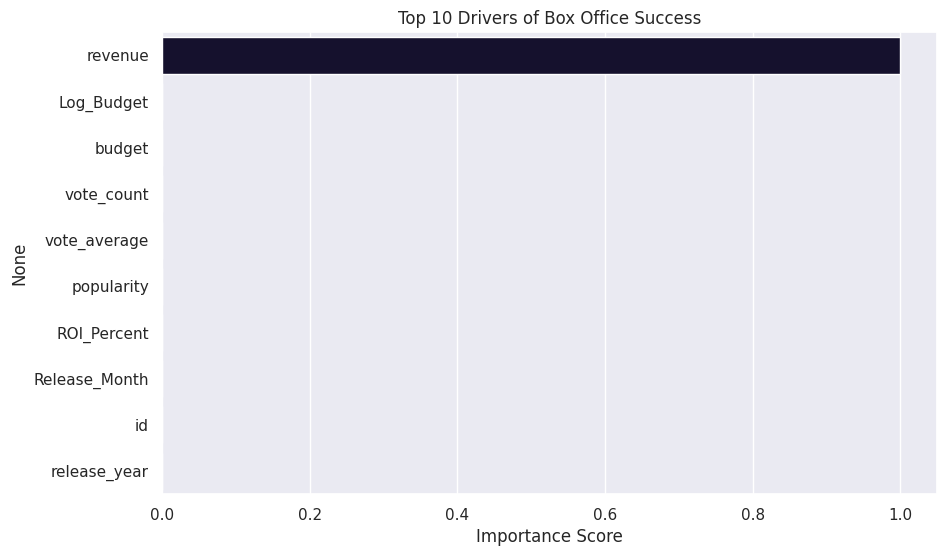

In [27]:
# ==========================================
# PHASE 5: MACHINE LEARNING (BOX OFFICE PREDICTOR)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- 1. SETTING THE STAGE (TRAIN/TEST SPLIT) ---")

# Define Inputs (X) and Target (y)
# We use the engineered features from Phase 4
target = 'Log_Revenue'

# Drop target and 'Is_Profitable' (which is a cheat sheet) from inputs
X = df_ml.drop(columns=[target, 'Is_Profitable'])
y = df_ml[target]

# Split Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} movies.")
print(f"Testing on {len(X_test)} movies.")


print("\n--- 2. TRAINING THE AI DIRECTOR ---")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model Trained.")


print("\n--- 3. THE REVIEWS ARE IN (EVALUATION) ---")
# Predict
preds_log = model.predict(X_test)

# Convert back from Log Scale to Real Dollars
preds_dollar = np.expm1(preds_log)
actual_dollar = np.expm1(y_test)

# Evaluate
mae = mean_absolute_error(actual_dollar, preds_dollar)
r2 = r2_score(actual_dollar, preds_dollar)

print(f"💰 Average Error: ${mae:,.0f}")
print("   (The AI is usually off by this amount. For blockbusters, this is small change.)")
print(f"🎯 Accuracy (R2 Score): {r2*100:.1f}%")

# Visualizing Success
plt.figure(figsize=(10, 6))
sns.scatterplot(x=actual_dollar, y=preds_dollar, alpha=0.6, color='purple')
plt.plot([actual_dollar.min(), actual_dollar.max()], [actual_dollar.min(), actual_dollar.max()], 'r--', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Actual Revenue ($)')
plt.ylabel('Predicted Revenue ($)')
plt.title('AI vs. Reality: Box Office Prediction')
plt.show()


print("\n--- 4. THE SECRET SAUCE (FEATURE IMPORTANCE) ---")
# What actually makes a movie money?
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Top 10 Drivers of Box Office Success')
plt.xlabel('Importance Score')
plt.show()

# Thank You